In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from numpy import linspace, arange
import numpy as np
import numpy.linalg as LA
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles
from sklearn.neighbors import kneighbors_graph
from sklearn.datasets import load_iris 
data = load_iris()

In [2]:
def colored(text,r,g,b):
    ''' make a string colored  '''
    return "\033[38;2;{};{};{}m{} \033[38;2;255;255;255m".format(r, g, b, text)

def make_Gaussian(k):
    X,Y=[],[]
    for i in range(k):
        x=arange(-1,1,0.1)+2*i
        y=norm.pdf(x, loc=2*i, scale=1)
        X.extend(x)
        Y.extend(y)
    return np.array(list(zip(X,Y)))

In [3]:
X, labels = make_circles(n_samples=500, noise=.1, factor=.2)

In [4]:
class SC():
    def __init__(self,data,k=2,adj='KNN',nn=7):
        self.data=data
        self.k=k
        self.adj=adj
        self.nn=nn
        
    def similarity(self):
        data=self.data
        def f(i,j):
            if i==j:
                return 0
            else:
                return np.exp(-LA.norm((np.array(data[i])-np.array(data[j]))**2)/50)
        
        if self.adj=='FCG':
            S=[[ f(i,j) for j in range(len(data))] for i in range(len(data))]
        if self.adj=='KNN': 
            S = kneighbors_graph(data, n_neighbors=self.nn).toarray()
        return np.array(S)  
    
    def laplace(self):
        S=self.similarity()
        D =np.diag(S.sum(axis=1))
        Dinv=LA.inv(D)
        L=Dinv**0.5@(D-S)@Dinv**0.5
        return L
    
    def vects(self):
        L=self.laplace()
        vals,eigenvects=LA.eig(L)
        eigenvects = eigenvects[:,np.argsort(vals)]
        vals = vals[np.argsort(vals)]
        return vals,eigenvects
    
    def labels(self):
        vals,vects=self.vects()
        if self.k==2:
            labels=vects[:,1]>0
        if self.k>2:
            kmeans=KMeans(n_clusters=self.k, random_state=1).fit(np.real(vects.T[1:self.k+1].T))
            labels=kmeans.labels_
        return labels
    
    def plotter(self):
        if len(self.data[0]==2):
            fig,ax=plt.subplots()
            ax.set_facecolor('black')
            ax.scatter(self.data[:,0],self.data[:,1],c=self.labels())
            #return fig

## Example 1


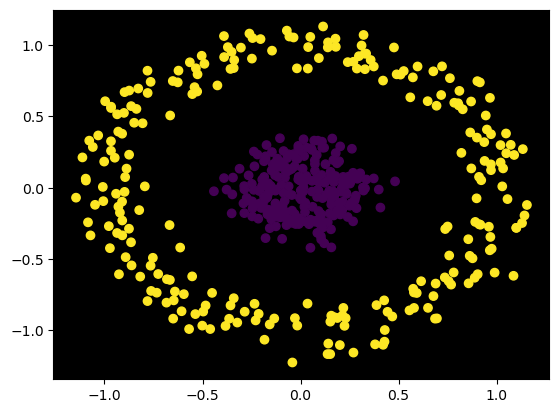

In [5]:
ex1=SC(X,nn=10)
ex1.plotter()


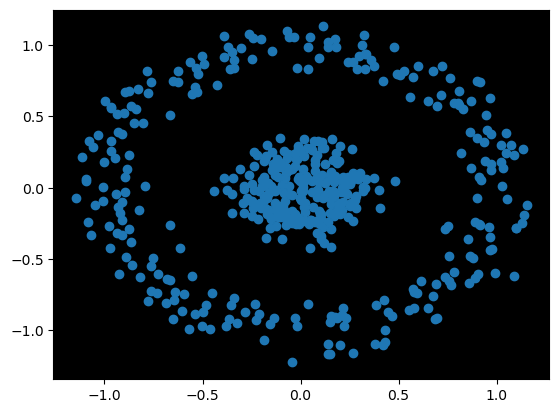

In [6]:
fig,ax=plt.subplots()
ax.set_facecolor('black')
ax.scatter(X[:,0],X[:,1])

## Example 2


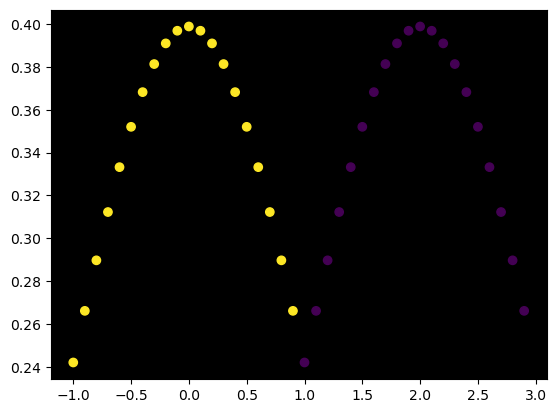

In [7]:
ex2=SC(make_Gaussian(2),nn=10)
ex2.plotter()

## Example 3

In [8]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df['target'] = pd.Series(data.target)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [69]:
def change(data):
    res=[]
    for i in data:
        if i==2:
            res.append(1)
        elif i==1:
            res.append(0)
        elif i==0:
            res.append(2)
    return np.array(res) 


In [70]:


ex3=SC(data.data,k=3,nn=3)
res=ex3.labels()
print(colored((sum(change(res)==data.target)/len(data.target)),152,29,227))


0.9533333333333334 


In [71]:
res

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [72]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])